# LH2 normalized pi0 yield by run

For every run, count the combined-file events selected by
`is_exclusive_ellipse_combined` with their producer `pi0_weight`:

$$Y_r = \frac{\mathrm{scale}_r}{1-0.00102 I_r}
          \sum_{i\in r,\;\mathrm{ellipse}_i=1} \mathrm{pi0\_weight}_i.$$

`scale` includes prescale, charge, livetime, and efficiency. $I_r$ is the
arithmetic mean of valid measured segment currents from the selection report.
The error bars use $\sqrt{\sum w_i^2}$ plus the stored `scale_err`; they do not
include uncertainty in the producer background subtraction or boiling model.
Relative yields use the run with the largest inverse-variance weight $1/\sigma^2$ as the reference. The denominator uncertainty is
propagated to other runs, so their relative errors share that uncertainty.
The run-number axis uses evenly spaced slots for the requested 14 runs;
empty slots have no entries in the combined ROOT input.
This notebook is a diagnostic of run-to-run stability.


In [17]:
from pathlib import Path

ROOT_FILE = Path(
    '/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/'
    'root_analysis_env_main/output/KinC_x36_5_407/KinC_x36_5/root/'
    'combined_branches_LH2.root'
)
CURRENT_CSV = Path(
    '/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/'
    'root_analysis_env_main/output/efficiency_stuff/'
    'selection_report_KinC_x36_5.csv'
)
KINEMATIC_SETTING = 'KinC_x36_5'
RUNS_TO_IGNORE = []  # Optional run numbers excluded from the table and trend.
RUN_AXIS = [3728, 3729, 3731, 3732, 3733, 3737, 3755, 3756, 3757,
            3758, 3759, 3760, 3762, 3767]  # Uniform display slots.
BOILING_COEFF_PER_UA = 0.00102


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
from IPython.display import display
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'figure.dpi': 160, 'savefig.dpi': 300,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.linewidth': 0.8, 'pdf.fonttype': 42,
})

branches = [
    'run_number', 'mpi0_all', 'mmiss_all', 'pi0_weight', 'scale', 'scale_err',
    'is_exclusive_ellipse_combined',
]
with uproot.open(ROOT_FILE) as root_file:
    data = root_file['physics'].arrays(branches, library='np')

currents = pd.read_csv(
    CURRENT_CSV,
    usecols=lambda name: name.strip() in {
        'run_number', 'kinematic_setting', 'segment_number',
        'selection_ok', 'mean_current_uA',
    },
)
currents.columns = currents.columns.str.strip()
currents['kinematic_setting'] = currents['kinematic_setting'].astype(str).str.strip(" \"'")
for name in ['run_number', 'segment_number', 'selection_ok', 'mean_current_uA']:
    currents[name] = pd.to_numeric(currents[name], errors='coerce')
currents = currents[
    currents['kinematic_setting'].eq(KINEMATIC_SETTING)
    & currents['selection_ok'].eq(1)
    & np.isfinite(currents['mean_current_uA'])
]
if currents.duplicated(['run_number', 'segment_number']).any():
    raise ValueError('Duplicate valid current segments in the selection report')
mean_current = currents.groupby('run_number')['mean_current_uA'].mean()

selected = data['is_exclusive_ellipse_combined'] == 1
runs = sorted(set(data['run_number']) - set(RUNS_TO_IGNORE))
rows = []
for run in runs:
    in_run = data['run_number'] == run
    in_ellipse = in_run & selected
    if not in_ellipse.any():
        raise ValueError(f'Run {run} has no combined-ellipse events')
    scale_values = data['scale'][in_run]
    scale_err_values = data['scale_err'][in_run]
    if not (np.allclose(scale_values, scale_values[0], rtol=2e-6)
            and np.allclose(scale_err_values, scale_err_values[0], rtol=2e-6)):
        raise ValueError(f'Run {run} has inconsistent normalization metadata')
    if run not in mean_current:
        raise ValueError(f'Run {run} has no valid measured current')
    current = float(mean_current.loc[run])
    density = 1 - BOILING_COEFF_PER_UA * current
    if density <= 0:
        raise ValueError(f'Run {run} has invalid LH2 density correction')
    weights = data['pi0_weight'][in_ellipse]
    if not np.isfinite(weights).all() or (weights <= 0).any():
        raise ValueError(f'Run {run} has invalid selected pi0 weights')
    scale = float(scale_values[0])
    scale_err = float(scale_err_values[0])
    signal = float(weights.sum())
    yield_per_mc = scale * signal / density
    sigma_stat = scale * np.sqrt(np.square(weights).sum()) / density
    sigma_scale = signal * scale_err / density
    rows.append({
        'run_number': int(run), 'current_uA': current,
        'selected_events': int(in_ellipse.sum()),
        'normalized_yield': yield_per_mc,
        'yield_error': float(np.hypot(sigma_stat, sigma_scale)),
    })

run_table = pd.DataFrame(rows)
display(run_table)


,run_number,current_uA,selected_events,normalized_yield,yield_error
0,3731,29.153467,2308,20.805337,0.442474
1,3732,14.679740,403,23.685513,1.192831
2,3733,8.037289,456,25.120148,1.183503
3,3737,28.334548,173,21.632503,1.676184
4,3755,29.680981,2219,21.699046,0.469663
5,3756,29.296978,1873,20.805268,0.489626
6,3757,21.277367,52,19.147067,2.722491
7,3759,28.977344,1048,21.217862,0.668212
8,3760,14.442580,313,27.979330,1.599322
9,3762,8.033492,554,26.186326,1.118965


<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:84: SyntaxWarning: invalid escape sequence '\p'
/scratch/singhav/ipykernel_2045857/3145806043.py:84: SyntaxWarning: invalid escape sequence '\p'
  fig.suptitle(f'{KINEMATIC_SETTING} LH2 exclusive $\pi^0$ yield stability',
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


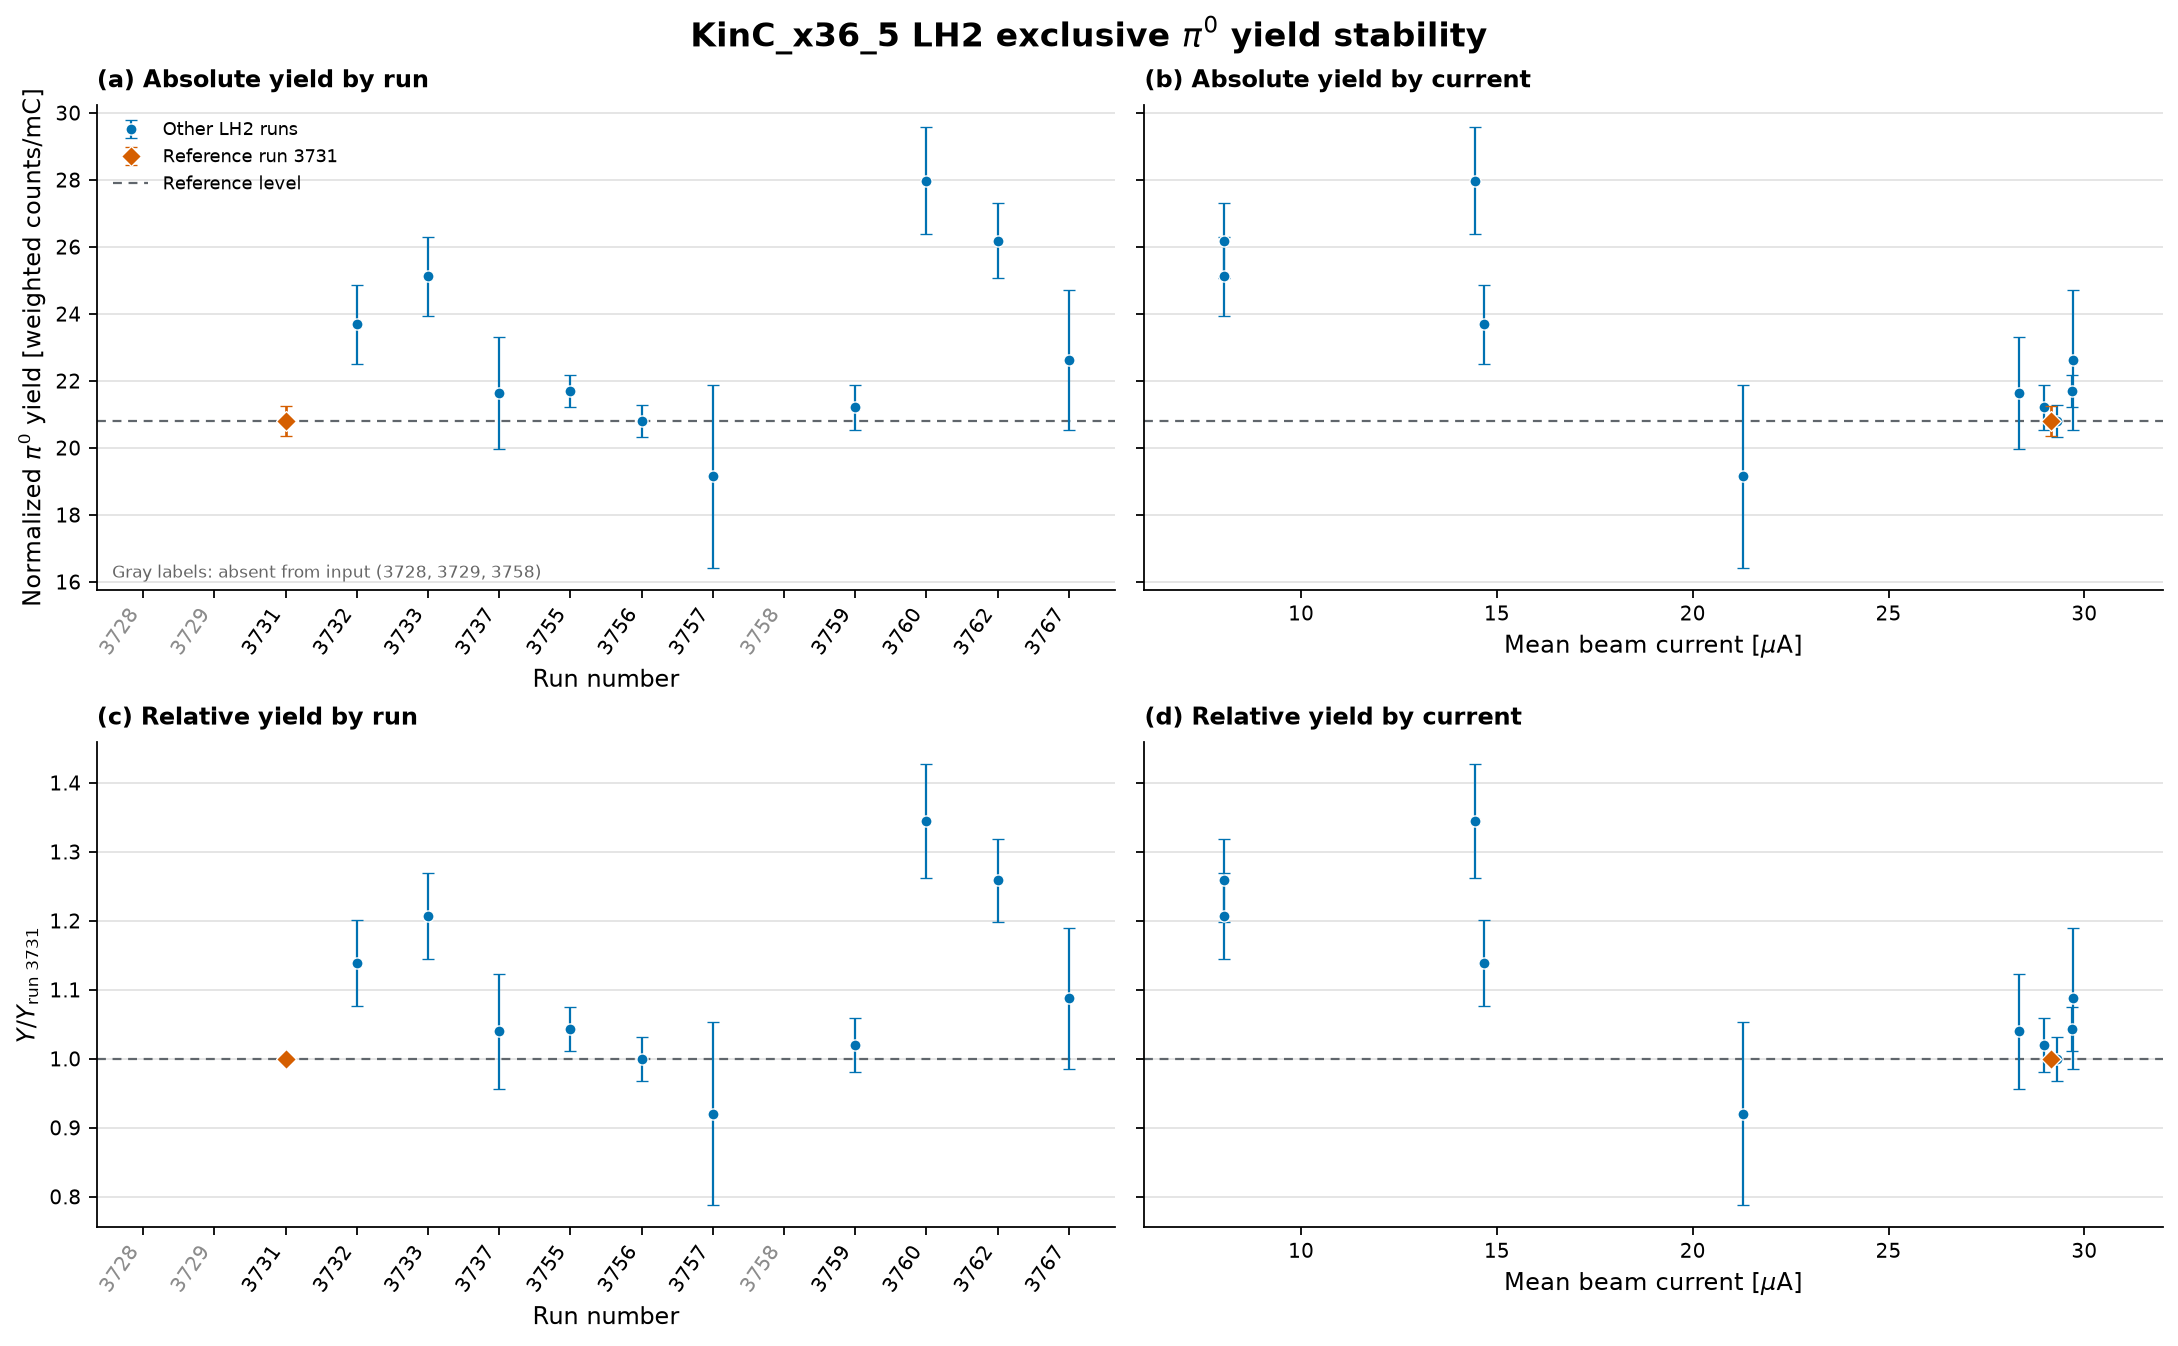

Reference run: 3731 (largest inverse-variance weight). Runs absent from combined input: [3728, 3729, 3758].


In [19]:
inverse_variance = 1 / run_table['yield_error']**2
reference_index = inverse_variance.idxmax()
reference_run = int(run_table.loc[reference_index, 'run_number'])
reference_yield = float(run_table.loc[reference_index, 'normalized_yield'])
reference_error = float(run_table.loc[reference_index, 'yield_error'])
run_table['relative_yield'] = run_table['normalized_yield'] / reference_yield
run_table['relative_error'] = np.sqrt(
    (run_table['yield_error'] / reference_yield)**2
    + (run_table['normalized_yield'] * reference_error / reference_yield**2)**2
)
run_table.loc[reference_index, 'relative_error'] = 0.0  # Y_ref / Y_ref is exact.

if len(RUN_AXIS) != len(set(RUN_AXIS)):
    raise ValueError('RUN_AXIS contains duplicate run numbers')
position = {run: i for i, run in enumerate(RUN_AXIS)}
unmapped = set(run_table['run_number']) - set(RUN_AXIS)
if unmapped:
    raise ValueError(f'Add these runs to RUN_AXIS: {sorted(unmapped)}')
run_x = run_table['run_number'].map(position).to_numpy(int)
missing_from_input = sorted(set(RUN_AXIS) - set(data['run_number']))
other = run_table.index != reference_index
blue, orange, gray = '#0072B2', '#D55E00', '#60666C'

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.3), sharey='row',
                         constrained_layout=True, dpi=160)
fig.patch.set_facecolor('white')
for row, (value, error, baseline, ylabel) in enumerate([
    ('normalized_yield', 'yield_error', reference_yield,
     r'Normalized $\pi^0$ yield [weighted counts/mC]'),
    ('relative_yield', 'relative_error', 1.0,
     rf'$Y / Y_{{\mathrm{{run}}\ {reference_run}}}$'),
]):
    y = run_table[value].to_numpy(float)
    sigma = run_table[error].to_numpy(float)
    for col, (x, xlabel) in enumerate([
        (run_x, 'Run number'),
        (run_table['current_uA'].to_numpy(float),
         r'Mean beam current [$\mu$A]'),
    ]):
        ax = axes[row, col]
        ax.errorbar(x[other], y[other], yerr=sigma[other], fmt='o',
                    ms=5, lw=0, elinewidth=1, capsize=2.5, capthick=1,
                    color=blue, mec='white', mew=0.6, zorder=3,
                    label='Other LH2 runs')
        ax.errorbar(x[~other], y[~other], yerr=sigma[~other], fmt='D',
                    ms=6.5, lw=0, elinewidth=1.2, capsize=2.5, capthick=1.2,
                    color=orange, mec='white', mew=0.6, zorder=4,
                    label=f'Reference run {reference_run}')
        ax.axhline(baseline, color=gray, lw=1, ls=(0, (4, 3)),
                   label='Reference level')
        ax.set_xlabel(xlabel)
        if col == 0:
            ax.set_ylabel(ylabel)
            ax.set_xticks(np.arange(len(RUN_AXIS)), [str(run) for run in RUN_AXIS],
                          rotation=55, ha='right')
            ax.set_xlim(-0.65, len(RUN_AXIS) - 0.35)
            for tick, run in zip(ax.get_xticklabels(), RUN_AXIS):
                if run in missing_from_input:
                    tick.set_color('0.55')
        else:
            ax.set_xlim(6, 32)
            ax.set_xticks(np.arange(10, 31, 5))
        ax.grid(axis='y', color='0.87', lw=0.7)
        ax.tick_params(direction='out', length=3.5, width=0.8)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)

for ax, title in zip(axes.flat, [
    '(a) Absolute yield by run', '(b) Absolute yield by current',
    '(c) Relative yield by run', '(d) Relative yield by current',
]):
    ax.set_title(title, loc='left', fontweight='semibold', pad=8)
handles, labels = axes[0, 0].get_legend_handles_labels()
legend_order = [labels.index(name) for name in (
    'Other LH2 runs', f'Reference run {reference_run}', 'Reference level'
)]
axes[0, 0].legend([handles[i] for i in legend_order],
                  [labels[i] for i in legend_order],
                  loc='upper left', frameon=False, fontsize=8)
if missing_from_input:
    missing_label = ', '.join(map(str, missing_from_input))
    axes[0, 0].text(0.015, 0.025, f'Gray labels: absent from input ({missing_label})',
                    transform=axes[0, 0].transAxes, fontsize=7.5, color='0.4')
fig.suptitle(f'{KINEMATIC_SETTING} LH2 exclusive $\pi^0$ yield stability',
             fontsize=15, fontweight='semibold')
plt.show()
print(f'Reference run: {reference_run} (largest inverse-variance weight). '
      f'Runs absent from combined input: {missing_from_input}.')


## Combined ellipse in the mass plane

The weighted 2D distribution uses `pi0_weight × scale`. The white curve uses
the producer's saved ellipse center, covariance, and cut value; it is the
boundary of `is_exclusive_ellipse_combined`.


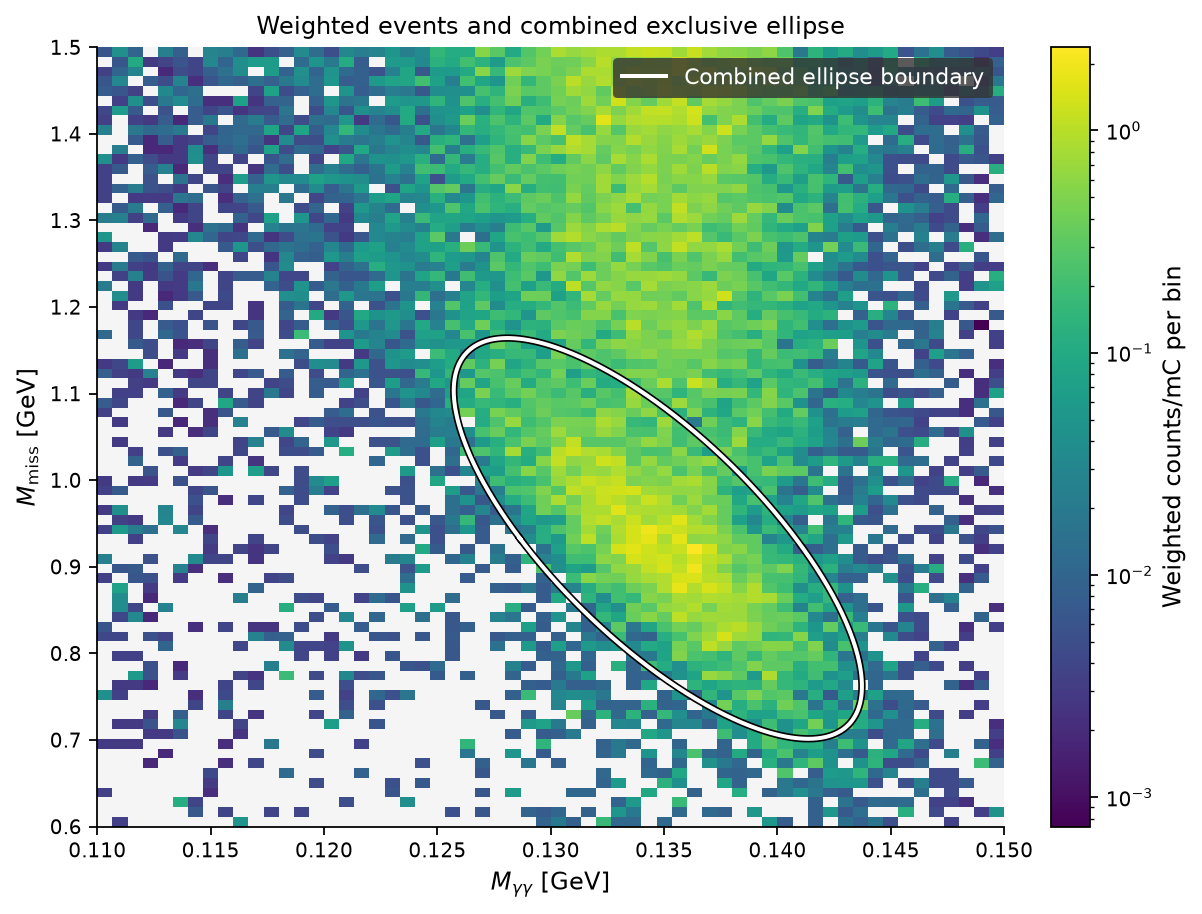

In [20]:
plot_runs = np.isin(data['run_number'], runs)
mass_valid = (plot_runs & np.isfinite(data['mpi0_all'])
              & np.isfinite(data['mmiss_all'])
              & np.isfinite(data['pi0_weight'])
              & np.isfinite(data['scale'])
              & (data['pi0_weight'] > 0))
x_edges = np.linspace(0.11, 0.15, 61)
y_edges = np.linspace(0.6, 1.5, 81)
event_weight = data['pi0_weight'] * data['scale']
hist, _, _ = np.histogram2d(
    data['mpi0_all'][mass_valid], data['mmiss_all'][mass_valid],
    bins=(x_edges, y_edges), weights=event_weight[mass_valid],
)

# The combine stage writes the covariance ellipse used for the event flag.
debug_file = ROOT_FILE.with_name(ROOT_FILE.stem + '_combined_2d_mass_cut_debug.txt')
ellipse_keys = {
    'mean_mpi0', 'mean_mmiss', 'cov_mpi0_mpi0', 'cov_mpi0_mmiss',
    'cov_mmiss_mmiss', 'ellipse_d2_cut',
}
parameters = {
    key: float(value)
    for line in debug_file.read_text().splitlines() if '=' in line
    for key, value in [line.split('=', 1)] if key in ellipse_keys
}
if set(parameters) != ellipse_keys:
    raise ValueError(f'Missing ellipse parameters in {debug_file}')
center = np.array([parameters['mean_mpi0'], parameters['mean_mmiss']])
covariance = np.array([
    [parameters['cov_mpi0_mpi0'], parameters['cov_mpi0_mmiss']],
    [parameters['cov_mpi0_mmiss'], parameters['cov_mmiss_mmiss']],
])
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
if (eigenvalues <= 0).any():
    raise ValueError('Invalid combined-ellipse covariance')
angle = np.linspace(0, 2 * np.pi, 400)
unit_circle = np.vstack((np.cos(angle), np.sin(angle)))
ellipse = center[:, None] + eigenvectors @ (
    np.sqrt(eigenvalues * parameters['ellipse_d2_cut'])[:, None] * unit_circle
)

positive = hist[hist > 0]
if not len(positive):
    raise ValueError('No weighted events in the 2D mass range')
fig, ax = plt.subplots(figsize=(7.4, 5.6), constrained_layout=True, dpi=160)
image = ax.pcolormesh(
    x_edges, y_edges, np.ma.masked_less_equal(hist.T, 0), cmap='viridis',
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
    shading='auto', rasterized=True,
)
ax.plot(ellipse[0], ellipse[1], color='black', lw=3.3, zorder=3)
ax.plot(ellipse[0], ellipse[1], color='white', lw=1.8, zorder=4,
        label='Combined ellipse boundary')
ax.set(xlabel=r'$M_{\gamma\gamma}$ [GeV]',
       ylabel=r'$M_{\mathrm{miss}}$ [GeV]',
       title='Weighted events and combined exclusive ellipse')
ax.set_facecolor('#f5f5f5')
ax.tick_params(direction='out', length=3.5, width=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.legend(facecolor='0.2', edgecolor='none', labelcolor='white')
fig.colorbar(image, ax=ax, pad=0.02, label='Weighted counts/mC per bin')
plt.show()
